# 🕵️ Módulo 3.5: Detección de Anomalías
### Curso: **Machine Learning con Python** (IFCD093PO)
**Duración estimada:** 6 horas

---

## 🎯 Objetivos del Módulo

Hemos llegado a la tercera y última gran tarea del aprendizaje no supervisado. La detección de anomalías, también conocida como detección de outliers, es el proceso de identificar elementos, eventos o observaciones que no se ajustan a un patrón esperado en un conjunto de datos. Estas "agujas en el pajar" son a menudo los puntos de datos más interesantes y críticos.

Al finalizar, serás capaz de:

- ✅ Entender qué es una anomalía y por qué su detección es crucial en muchas industrias (fraude, ciberseguridad, etc.).
- ✅ Aplicar **Isolation Forest**, un algoritmo eficiente basado en árboles para aislar anomalías.
- ✅ Utilizar **Local Outlier Factor (LOF)**, un algoritmo basado en densidad que compara la densidad local de un punto con la de sus vecinos.
- ✅ Implementar **One-Class SVM**, una adaptación de las Support Vector Machines para aprender una frontera alrededor de los datos "normales".
- ✅ Elegir el algoritmo de detección de anomalías más adecuado según las características de tus datos.

**¡Prepárate para convertirte en un detective de datos y encontrar las pistas más inusuales y valiosas!**
 
---

## 📚 Tabla de Contenidos

1. [¿Qué es la Detección de Anomalías?](#1-que-es)
   - [Tipos de Anomalías](#1.1-tipos)
   - [Aplicaciones en el Mundo Real](#1.2-aplicaciones)
2. [Preparación de Datos](#2-preparacion)
3. [Isolation Forest](#3-isoforest)
   - [Intuición: Aislando Puntos con Árboles Aleatorios](#3.1-intuicion-isoforest)
   - [Implementación con Scikit-Learn](#3.2-implementacion-isoforest)
4. [Local Outlier Factor (LOF)](#4-lof)
   - [Intuición: Comparando Densidades Locales](#4.1-intuicion-lof)
   - [Implementación con Scikit-Learn](#4.2-implementacion-lof)
5. [One-Class SVM](#5-oneclass-svm)
   - [Intuición: Aprendiendo una Frontera para lo Normal](#5.1-intuicion-svm)
   - [Implementación con Scikit-Learn](#5.2-implementacion-svm)
6. [Comparativa de Algoritmos](#6-comparativa)
7. [Resumen y Próximos Pasos](#7-resumen)

---

## ❓ 1. ¿Qué es la Detección de Anomalías? <a id='1-que-es'></a>

La detección de anomalías es una técnica de minería de datos para identificar puntos de datos raros que se desvían significativamente de la mayoría de los datos. Estos puntos se conocen como **anomalías** u **outliers**.

### 1.1 Tipos de Anomalías <a id='1.1-tipos'></a>

- **Anomalías Puntuales**: Un punto de datos individual que se considera anómalo con respecto al resto. Es el tipo más común. (Ej: una transacción de 10.000€ cuando la media es 50€).
- **Anomalías Contextuales**: Una observación que es anómala en un contexto específico, pero no en otro. (Ej: gastar 500€ en regalos es normal en diciembre, pero anómalo en agosto).
- **Anomalías Colectivas**: Un conjunto de observaciones que, en conjunto, son anómalas, aunque individualmente no lo sean. (Ej: un ritmo cardíaco plano en un electrocardiograma).

### 1.2 Aplicaciones en el Mundo Real <a id='1.2-aplicaciones'></a>

- **Detección de Fraude**: Identificar transacciones con tarjeta de crédito, reclamaciones de seguros o clics en anuncios que son fraudulentos.
- **Ciberseguridad**: Detectar intrusiones en la red o comportamientos maliciosos.
- **Mantenimiento Predictivo**: Monitorizar sensores en maquinaria industrial para detectar lecturas anómalas que puedan indicar un fallo inminente.
- **Salud**: Encontrar valores anómalos en pruebas médicas que puedan señalar una enfermedad.
- **Control de Calidad**: Identificar productos defectuosos en una cadena de producción.

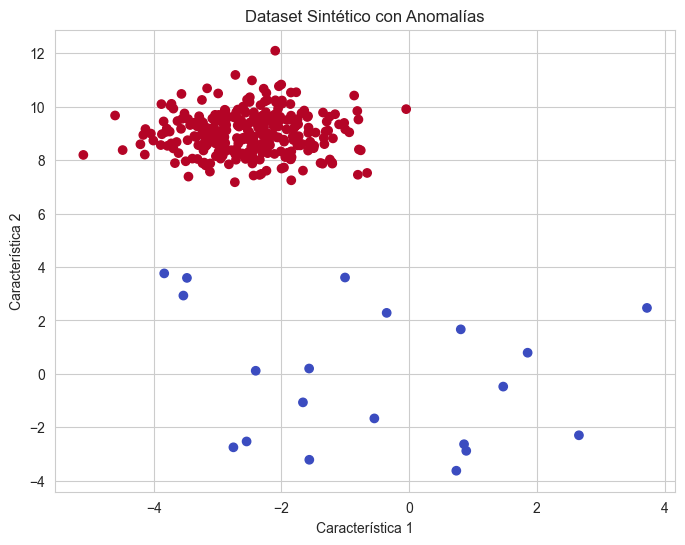

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

sns.set_style('whitegrid')

# --- Dataset Sintético ---
# Creamos un conjunto de datos normal y luego añadimos algunos outliers
X_main, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.8, random_state=42) # Datos principales

# Añadimos outliers
rng = np.random.RandomState(42) # Generador de números aleatorios
X_outliers = rng.uniform(low=-4, high=4, size=(20, 2)) # Datos de outliers

# Concatenamos los datos
X = np.vstack([X_main, X_outliers]) # Conjunto de datos completo

# Creamos las etiquetas para visualización (1 para inliers, -1 para outliers)
y_true = np.ones(len(X), dtype=int) # Etiquetas verdaderas
y_true[-len(X_outliers):] = -1 # Etiquetas de outliers

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm')
plt.title('Dataset Sintético con Anomalías')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

---

## 🌳 3. Isolation Forest <a id='3-isoforest'></a>

Isolation Forest es un algoritmo de ensemble, similar a Random Forest, pero diseñado específicamente para la detección de anomalías.

### 3.1 Intuición: Aislando Puntos con Árboles Aleatorios <a id='3.1-intuicion-isoforest'></a>

La idea principal es ingeniosa y simple:

> **Las anomalías son más fáciles de "aislar" que los puntos normales.**

El algoritmo funciona así:
1.  Construye múltiples árboles de decisión aleatorios (`Isolation Trees`).
2.  En cada árbol, para "aislar" un punto, se realizan cortes aleatorios en características aleatorias hasta que el punto queda solo en un nodo.
3.  Los puntos anómalos, al estar lejos de la masa de datos, requerirán muy pocos cortes para ser aislados. Estarán en rutas más cortas desde la raíz del árbol.
4.  Los puntos normales, al estar en zonas densas, necesitarán muchos más cortes para ser aislados.
5.  El "score de anomalía" de un punto se basa en la longitud promedio de la ruta para aislarlo en todos los árboles del bosque.

![Isolation Forest](imagenes/isolation_forest.png)

Número de anomalías encontradas por Isolation Forest: 33


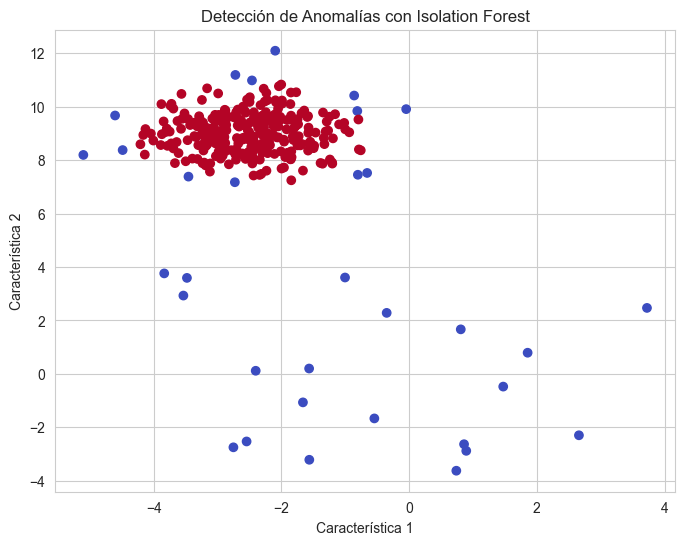

In [3]:
# El hiperparámetro 'contamination' indica la proporción esperada de outliers
# Lo ponemos en 'auto' o podemos darle un valor como 0.1 (10%)
iso_forest = IsolationForest(contamination="auto", random_state=42)

y_pred_iso = iso_forest.fit_predict(X) # Predicciones del modelo

# Los resultados son 1 para inliers y -1 para outliers
print(f"Número de anomalías encontradas por Isolation Forest: {np.sum(y_pred_iso == -1)}")

# Visualización
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred_iso, cmap='coolwarm')
plt.title('Detección de Anomalías con Isolation Forest')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

**Análisis:** Isolation Forest hace un buen trabajo identificando la mayoría de los puntos que añadimos como outliers. Es rápido y funciona bien en datasets de alta dimensión.

---

## 📍 4. Local Outlier Factor (LOF) <a id='4-lof'></a>

LOF es un algoritmo basado en densidad, pero en lugar de encontrar clústeres como DBSCAN, se enfoca en la densidad local de cada punto.

### 4.1 Intuición: Comparando Densidades Locales <a id='4.1-intuicion-lof'></a>

La idea clave de LOF es:

> **Un punto es anómalo si su densidad local es significativamente menor que la de sus vecinos.**

El algoritmo calcula un score (el "factor de outlier local") para cada punto:
1.  Para un punto `p`, encuentra sus `k` vecinos más cercanos.
2.  Calcula la "densidad local" de `p` basándose en la distancia a sus vecinos.
3.  Compara la densidad de `p` con la densidad promedio de sus `k` vecinos.
4.  Si la densidad de `p` es mucho menor, su score LOF será alto, indicando que es un outlier.

Esto permite a LOF encontrar outliers que están en regiones de diferente densidad, algo que Isolation Forest podría pasar por alto.

Número de anomalías encontradas por LOF: 33


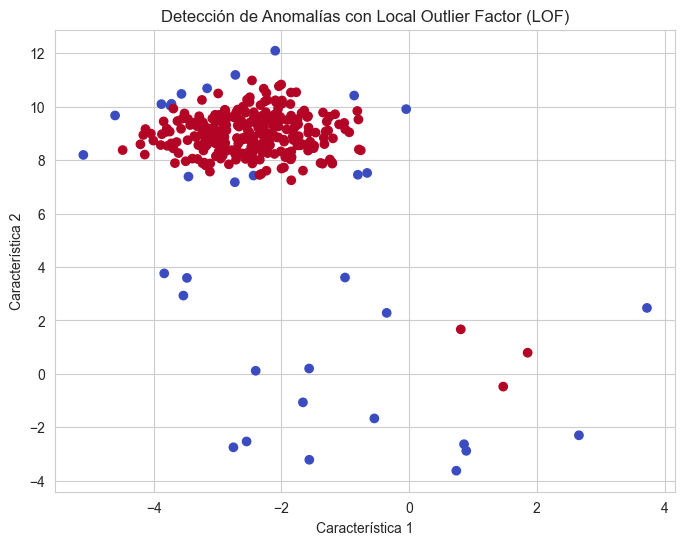

In [9]:
# n_neighbors es el hiperparámetro clave (k)
# contamination='auto' es una buena opción por defecto
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')

y_pred_lof = lof.fit_predict(X)

print(f"Número de anomalías encontradas por LOF: {np.sum(y_pred_lof == -1)}")

# Visualización
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred_lof, cmap='coolwarm')
plt.title('Detección de Anomalías con Local Outlier Factor (LOF)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

**Análisis:** LOF también identifica correctamente la mayoría de los outliers. Es particularmente bueno para encontrar anomalías que están "cerca" de clústeres pero en zonas de menor densidad.

---

## ⭕ 5. One-Class SVM <a id='5-oneclass-svm'></a>

One-Class SVM es una adaptación de las Support Vector Machines para el aprendizaje no supervisado y la detección de anomalías.

### 5.1 Intuición: Aprendiendo una Frontera para lo Normal <a id='5.1-intuicion-svm'></a>

Mientras que una SVM normal busca encontrar un hiperplano que separe dos clases, la One-Class SVM intenta encontrar una **frontera que englobe a la mayoría de los datos "normales"**.

Vamos a ver una explicación sencilla y un ejemplo visual para entender el concepto:

Imagina que tienes una cerca y solo quieres proteger a tu rebaño de ovejas. No tienes lobos (la otra clase) para entrenar a tu perro guardián; solo tienes ovejas.

Objetivo de OCSVM: Aprender qué es "normal" y construir la cerca más eficiente a su alrededor.

- **Datos "Normales" (Las Ovejas)**: Todos tus datos de entrenamiento son la clase positiva (lo que consideras normal o esperado). El algoritmo asume: todo lo que me muestras está bien.

- **La Frontera (La Cerca)**: OCSVM dibuja un límite ajustado alrededor de estas ovejas, aíslando la manada del vasto espacio vacío (el origen). Piensa en esto como poner la cerca lo más cerca posible de las ovejas sin encerrar demasiado aire.

- **El Origen (El Espacio Vacío)**: El origen del espacio de características es esencialmente el "vacío" o el concepto de "nada". OCSVM separa los datos "normales" (las ovejas) de la "nada" (el origen).

- **Anomalía (El Lobo)**: Cualquier nuevo punto de datos (el lobo) que se encuentra fuera de la cerca se clasifica como una anomalía o un outlier, simplemente porque no se parece a nada de lo que vio durante el entrenamiento.

![Isolation Forest](imagenes/OCSVM.png)

Es especialmente útil cuando se tiene un conjunto de datos "puro" que se sabe que solo contiene observaciones normales.

### 🖼️ Ejemplo Visual: Detección de Transacciones Bancarias Fraudulentas

Imagina que estás entrenando un modelo para detectar fraudes en un banco. La gran mayoría de las transacciones son legítimas. Solo el 0.1% son fraudulentas.

1. **El Entrenamiento (Definir lo Normal)**

    - **Datos de Entrenamiento**: Solo usas datos de transacciones legítimas. El modelo nunca ve un fraude.

    - **Visualización**: Graficamos las transacciones usando características clave (monto, ubicación, hora, etc.). .

    - **OCSVM Aprende**: El algoritmo OCSVM aprende a dibujar una hiperesfera o contorno muy ajustado alrededor de esta densa nube de transacciones normales.

2. **El Parámetro nu (El Margen de Error)**

    - El hiperparámetro $\nu$ (nu) es crucial.

    El valor de $\nu$ especifica la fracción esperada de observaciones de entrenamiento que serán tratadas como outliers (puntos fuera de la frontera), y también el error que se espera en los datos nuevos.

    Si estableces $\nu = 0.01$ (1%), le dices al modelo: "Sé que el 1% de mis transacciones de entrenamiento podrían ser anómalas por error, y quiero que tu frontera permita que aproximadamente el 1% de ellas caigan fuera."

3. **La Predicción (Identificar la Anomalía)**

    Cuando llega una nueva transacción:

    - Transacción Legítima: Si la nueva transacción cae dentro de la frontera aprendida, se etiqueta como NORMAL.

    - Transacción Fraudulenta: Si la transacción es una compra de $10,000 en el extranjero hecha a las 3:00 AM (una combinación de características muy diferente), esta cae fuera de la cerca. El OCSVM la clasifica como ANOMALÍA (fraude).

En resumen, la OCSVM es ideal para escenarios donde la clase de anomalía es rara o desconocida, y solo puedes recopilar un conjunto de datos robusto de lo que es "normal".

 ### El "truco del kernel" (Kernel Trick)

 El "truco del kernel" (Kernel Trick) es lo que le da al One-Class SVM (y a muchos otros algoritmos de SVM) su poder de manejar datos complejos y no lineales de una manera muy eficiente.
 
 #### El Truco del Kernel: De un Círculo a un Contorno Complejo
 
 La idea central es: si no puedes separar tus datos con una línea o un círculo en el espacio original, mapea los datos a un espacio de mayor dimensión donde la separación se vuelva fácil.
 
 1. **El Problema en 2D (Frontera Simple)**
 
    Imagina tus datos normales (transacciones legítimas) formando una nube con una forma compleja, como una medialuna o una "S", y quieres dibujar una frontera ajustada a su alrededor.
 
    - Si intentas usar un círculo (o un hiperplano) para rodear esta forma compleja, fracasarás. El círculo tendrá que ser enorme para cubrir todas las partes de la "S", lo que dejaría mucho espacio vacío dentro de la frontera, y clasificaría erróneamente muchas anomalías futuras como normales.
    
2. **El Truco del Kernel (La Magia) ✨**

    El truco del kernel utiliza una función matemática (el kernel, como el Kernel Gaussiano o RBF) que, sin calcularlo explícitamente, hace lo siguiente:
    
    - Mapeo a Alta Dimensión: El kernel eleva conceptualmente los datos del espacio 2D a un espacio de mayor dimensión (a veces, a un espacio infinito). Piensa en esto como estirar el papel 2D en una forma 3D compleja.
    
    - Separación Sencilla: En este nuevo espacio 3D, la forma compleja "S" de tus datos normales de repente se convierte en un grupo fácil de rodear con un plano o una esfera simple.
    
3. **La Solución en 2D (Frontera Compleja)**

    Cuando esta frontera simple (el plano 3D) se proyecta de nuevo al espacio 2D original, ya no parece un simple círculo. Ahora parece un contorno complejo y flexible que se ajusta perfectamente a la forma de medialuna o de "S" de tus datos normales.
    
    - Resultado: El OCSVM logra dibujar una frontera altamente no lineal alrededor de lo que es normal, ajustándose a la complejidad de los datos, mientras que solo tuvo que calcular una separación simple en el espacio de alta dimensión.
    
    |Característica|Sin Truco del Kernel (SVM Lineal)|Con Truco del Kernel (OCSVM RBF)|
    |--------------|---------------------------------|--------------------------------|
    |Frontera de Clase|Una línea recta (2D) o un plano.|Una forma compleja, curva y flexible.
    |Espacio Operativo|El espacio original de las características.|Conceptualmente, un espacio de dimensiones muy altas.
    |Poder de Ajuste|Bajo, solo para datos linealmente separables.|Alto, se ajusta a formas no lineales como una "S" o un anillo.|
    
    El kernel más usado para la OCSVM es el Kernel Gaussiano (RBF), ya que es excelente para definir "regiones de normalidad" y clasificar cualquier cosa que esté lejos de esa región como una anomalía.

Número de anomalías encontradas por One-Class SVM: 33


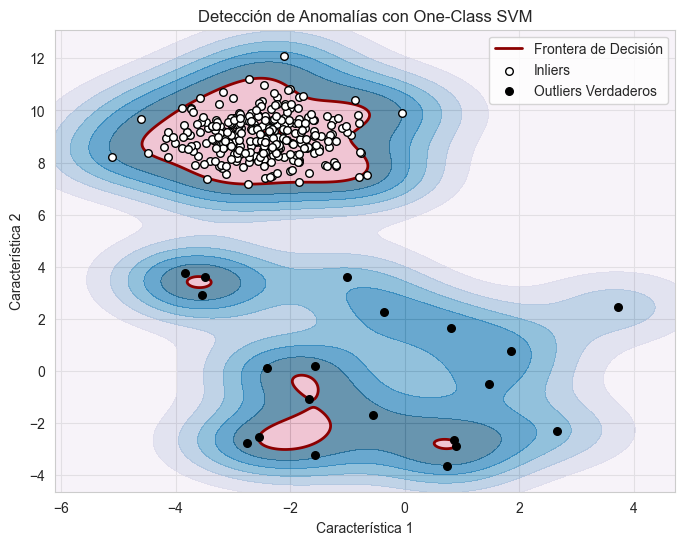

In [10]:
# nu es el hiperparámetro clave. Es un límite superior en la fracción de errores de entrenamiento
# y un límite inferior en la fracción de vectores de soporte. Debe estar en (0, 1].
one_class_svm = OneClassSVM(nu=0.1, kernel='rbf', gamma='auto')

y_pred_svm = one_class_svm.fit_predict(X)

print(f"Número de anomalías encontradas por One-Class SVM: {np.sum(y_pred_svm == -1)}")

# Visualización de la frontera de decisión (malla basada en los límites de los datos)
pad = 1.0
x_min, x_max = X[:,0].min() - pad, X[:,0].max() + pad
y_min, y_max = X[:,1].min() - pad, X[:,1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
Z = one_class_svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.title("Detección de Anomalías con One-Class SVM")
# Contornos con transparencia y zorder bajo
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu, alpha=0.6, zorder=1)
contour_border = plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkred', zorder=2)
plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors='palevioletred', alpha=0.4, zorder=1)

s = 30
b1 = plt.scatter(X[:-len(X_outliers), 0], X[:-len(X_outliers), 1], c='white', s=s, edgecolors='k', zorder=3)
b2 = plt.scatter(X[-len(X_outliers):, 0], X[-len(X_outliers):, 1], c='black', s=s, edgecolors='k', zorder=3)

from matplotlib.lines import Line2D
boundary_proxy = Line2D([0], [0], color='darkred', lw=2)
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend([boundary_proxy, b1, b2], ["Frontera de Decisión", "Inliers", "Outliers Verdaderos"], loc="upper right")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

**Análisis:** La visualización muestra claramente la frontera que One-Class SVM ha aprendido. Los puntos que caen fuera de la región roja oscura se clasifican como anomalías. Funciona bien para encontrar una envolvente general alrededor de los datos normales.

---

## 📊 6. Comparativa de Algoritmos <a id='6-comparativa'></a>

| Característica | Isolation Forest | Local Outlier Factor (LOF) | One-Class SVM |
| :--- | :--- | :--- | :--- |
| **Principio** | Aislamiento | Densidad Local | Frontera / Soporte |
| **Velocidad** | Muy Rápido | Lento | Rápido a Medio |
| **Escalabilidad** | Alta | Baja | Media |
| **Parámetros Clave** | `contamination` | `n_neighbors`, `contamination` | `nu`, `kernel`, `gamma` |
| **Fortalezas** | Rápido, bueno en alta dimensión | Detecta outliers en densidades variables | Bueno con datos "puros", base teórica sólida |
| **Debilidades** | Lucha con densidades variables | Costoso computacionalmente | Sensible a los parámetros del kernel |
| **Casos de Uso** | Primera línea de defensa, big data | Cuando la densidad local es importante | Novedad/detección de outliers con datos normales |

---

## 📝 7. Resumen y Próximos Pasos <a id='7-resumen'></a>

### 🎉 ¡Has completado el Módulo de Aprendizaje No Supervisado!

#### ✅ Lo que has aprendido:

1. **Clustering**: Agrupar datos con K-Means, Jerárquico y DBSCAN.
2. **Reducción de Dimensionalidad**: Simplificar y visualizar datos con PCA, t-SNE y UMAP.
3. **Detección de Anomalías**: Encontrar outliers con Isolation Forest, LOF y One-Class SVM.

Has adquirido un conjunto de herramientas increíblemente potente para explorar datos cuando no tienes etiquetas que te guíen. Eres capaz de encontrar segmentos de clientes, visualizar la estructura oculta de tus datos y detectar fraudes o fallos.

---

### 🚀 Próximo Módulo: Proyectos Finales

Es hora de poner a prueba todo lo que has aprendido. En el próximo módulo, te enfrentarás a tres proyectos de principio a fin, aplicando las técnicas de los módulos anteriores a problemas del mundo real.

1.  **Proyecto de Clasificación**: Predicción de fuga de clientes (Churn).
2.  **Proyecto de Regresión**: Estimación del valor de alquiler de propiedades.
3.  **Proyecto de Clustering**: Segmentación de clientes de un e-commerce.

**Has aprendido la teoría y la práctica de las herramientas individuales. Ahora, ¡vamos a integrarlo todo para resolver problemas complejos de negocio!**